In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('Customer_Data.csv')
df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
df.shape

(6418, 32)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   object 
 1   Gender                       6418 non-null   object 
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   object 
 4   State                        6418 non-null   object 
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   2870 non-null   object 
 8   Phone_Service                6418 non-null   object 
 9   Multiple_Lines               5796 non-null   object 
 10  Internet_Service             6418 non-null   object 
 11  Internet_Type                5028 non-null   object 
 12  Online_Security              5028 non-null   object 
 13  Online_Backup     

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Gender,0
Age,0
Married,0
State,0
Number_of_Referrals,0
Tenure_in_Months,0
Value_Deal,3548
Phone_Service,0
Multiple_Lines,622


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000
mean,47.070739,7.427859,17.342786,63.652867,2280.374858,1.924944,6.718604,748.703468,3033.871987
std,16.703633,4.621519,10.576391,31.188823,2268.049985,7.849083,24.722533,847.672844,2866.505426
min,18.000000,0.000000,1.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,33.000000,3.000000,8.000000,30.562500,395.725000,0.000000,0.000000,70.805000,603.742500
50%,46.000000,7.000000,16.000000,70.100000,1396.125000,0.000000,0.000000,407.475000,2108.635000
75%,60.000000,11.000000,27.000000,89.750000,3783.600000,0.000000,0.000000,1182.917500,4801.537500
max,85.000000,15.000000,36.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [ ]:
df['Customer_Status']

,Customer_Status
0,Stayed
1,Stayed
2,Churned
3,Churned
4,Churned
...,...
6413,Churned
6414,Stayed
6415,Churned
6416,Stayed


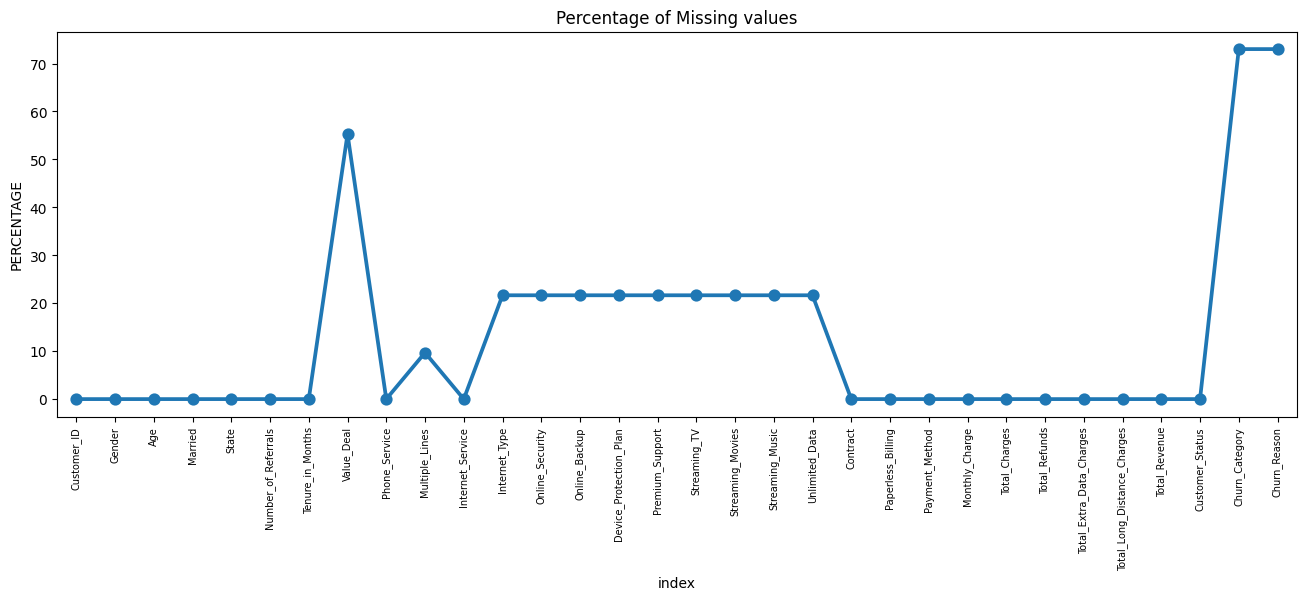

In [ ]:
missing = pd.DataFrame((df.isnull().sum())*100/df.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index', y=0, data=missing)
plt.xticks(rotation =90,fontsize =7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

In [ ]:
df['Customer_Status'].value_counts()

,count
Customer_Status,
Stayed,4275
Churned,1732
Joined,411


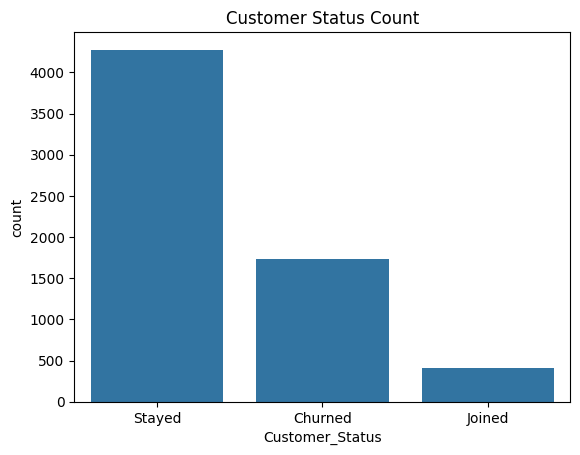

In [ ]:
sns.countplot(data=df, x='Customer_Status')
plt.title('Customer Status Count')
plt.show()

In [ ]:
churn_flag = np.where(df['Customer_Status'] == 'Churned', 1, 0)
churn_rate = np.mean(churn_flag)
print("Overall churn rate:", round(churn_rate * 100, 2), "%")

Overall churn rate: 26.99 %


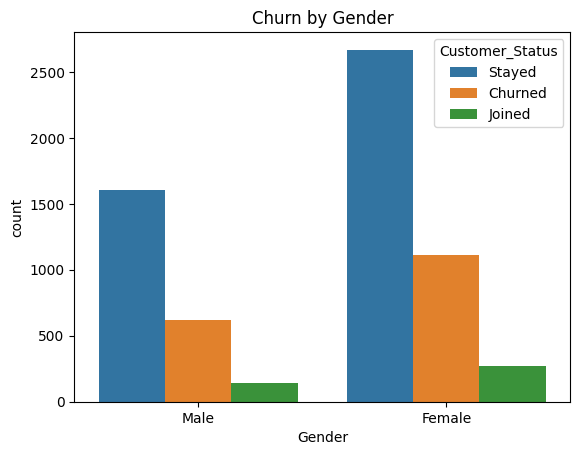

In [ ]:
sns.countplot(data=df, x='Gender', hue='Customer_Status')
plt.title('Churn by Gender')
plt.show()

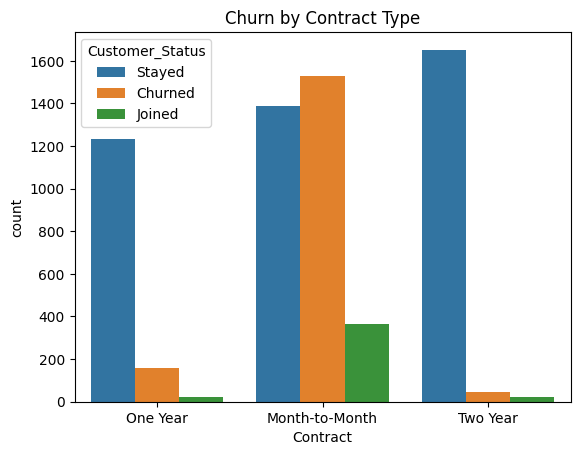

In [ ]:
sns.countplot(data=df, x='Contract', hue='Customer_Status')
plt.title('Churn by Contract Type')
plt.show()

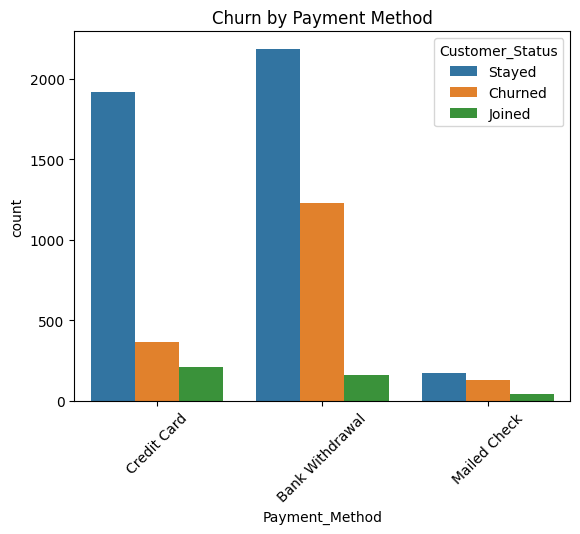

In [ ]:
sns.countplot(data=df, x='Payment_Method', hue='Customer_Status')
plt.title('Churn by Payment Method')
plt.xticks(rotation=45)
plt.show()

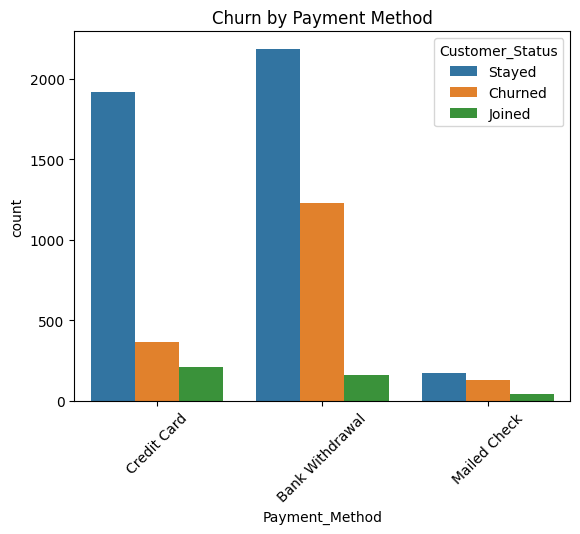

In [ ]:
sns.countplot(data=df, x='Payment_Method', hue='Customer_Status')
plt.title('Churn by Payment Method')
plt.xticks(rotation=45)
plt.show()

In [ ]:
print("Mean age:", np.mean(df['Age']))
print("Median age:", np.median(df['Age']))
print("Std dev age:", np.std(df['Age']))

Mean age: 47.07073854783422
Median age: 46.0
Std dev age: 16.7023317177045


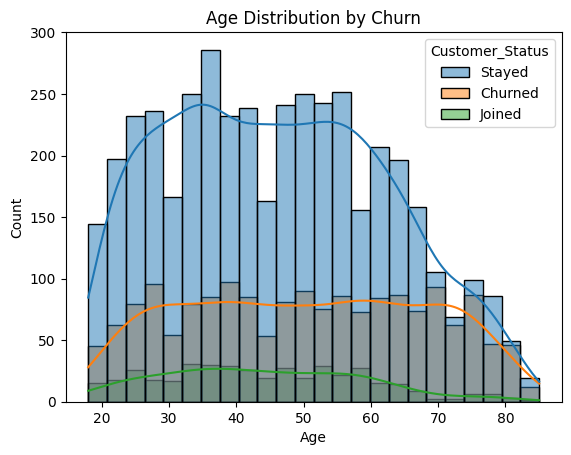

In [ ]:
sns.histplot(data=df, x='Age', hue='Customer_Status', kde=True)
plt.title('Age Distribution by Churn')
plt.show()

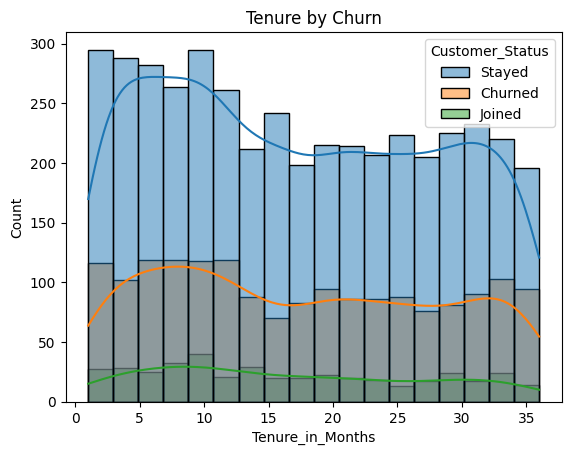

In [ ]:
sns.histplot(data=df, x='Tenure_in_Months', hue='Customer_Status', kde=True)
plt.title('Tenure by Churn')
plt.show()

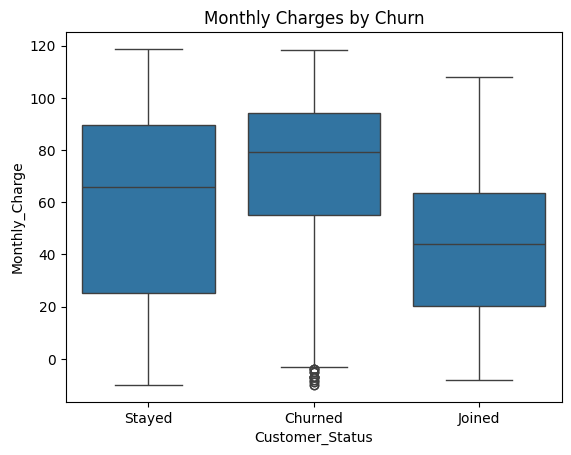

In [ ]:
sns.boxplot(data=df, x='Customer_Status', y='Monthly_Charge')
plt.title('Monthly Charges by Churn')
plt.show()

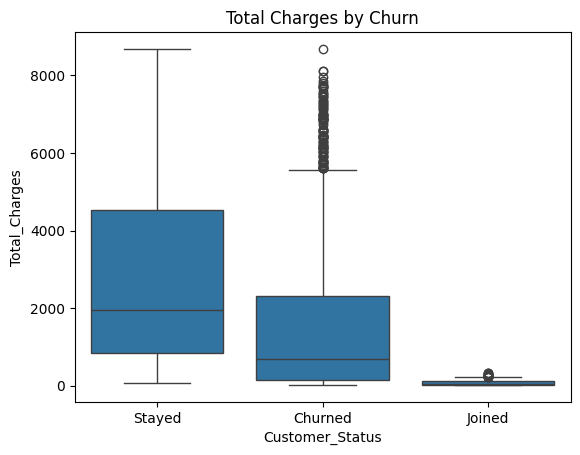

In [ ]:
sns.boxplot(data=df, x='Customer_Status', y='Total_Charges')
plt.title('Total Charges by Churn')
plt.show()

In [ ]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']

df['Tenure_Group'] = pd.cut(df['Tenure_in_Months'], bins=bins, labels=labels)
df.groupby('Tenure_Group', observed=False)['Tenure_in_Months'].count()

,Tenure_in_Months
Tenure_Group,
0-12,2551
13-24,1924
25-36,1943
37-48,0
49-60,0
61-72,0


In [ ]:
tenure_churn = df.groupby('Tenure_Group', observed=True).apply(
    lambda x: np.mean(np.where(x['Customer_Status'] == 'Churned', 1, 0)) if not x.empty else np.nan
)
print(tenure_churn)

Tenure_Group
0-12     0.271658
13-24    0.263514
25-36    0.273803
dtype: float64


/tmp/ipykernel_730/1492719995.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tenure_churn = df.groupby('Tenure_Group', observed=True).apply(


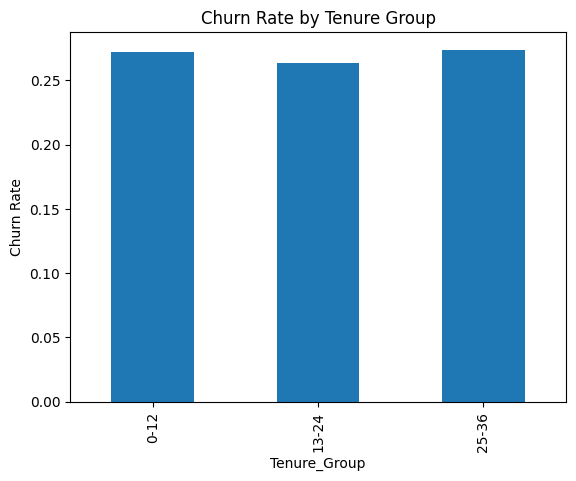

In [ ]:
tenure_churn.plot(kind='bar')
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate')
plt.show()

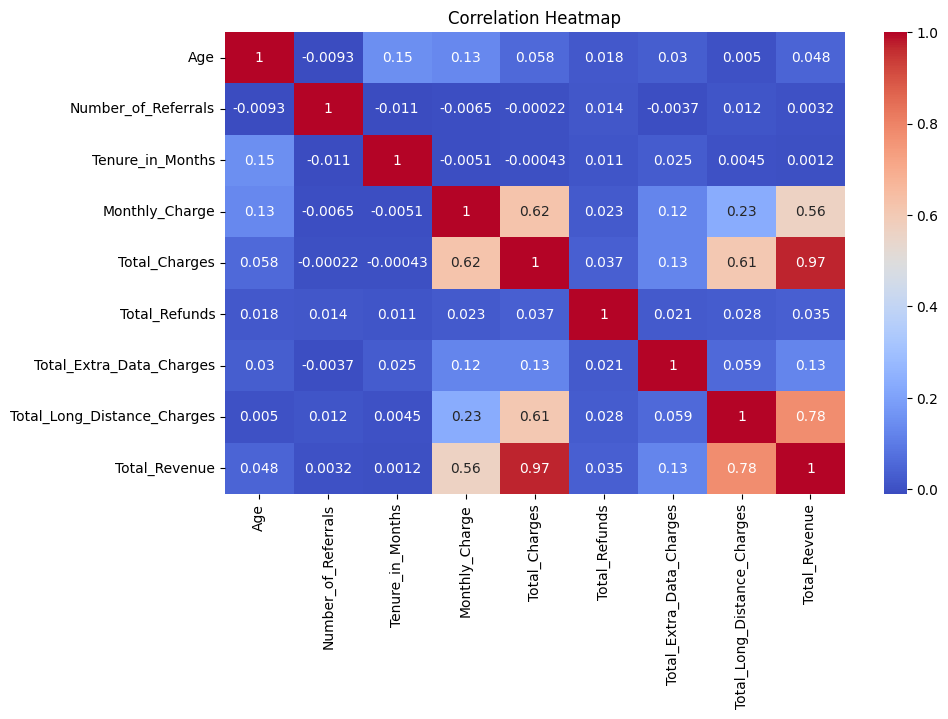

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
Q1 = np.percentile(df['Monthly_Charge'].dropna(), 25)
Q3 = np.percentile(df['Monthly_Charge'].dropna(), 75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

outliers = df[(df['Monthly_Charge'] < lower_limit) | (df['Monthly_Charge'] > upper_limit)]
print("Number of outliers:", outliers.shape[0])

Lower limit: -58.21875
Upper limit: 178.53125
Number of outliers: 0


In [ ]:
df[df['Customer_Status'] == 'Churned']['Churn_Category'].value_counts()

,count
Churn_Category,
Competitor,761
Attitude,301
Dissatisfaction,300
Price,196
Other,174


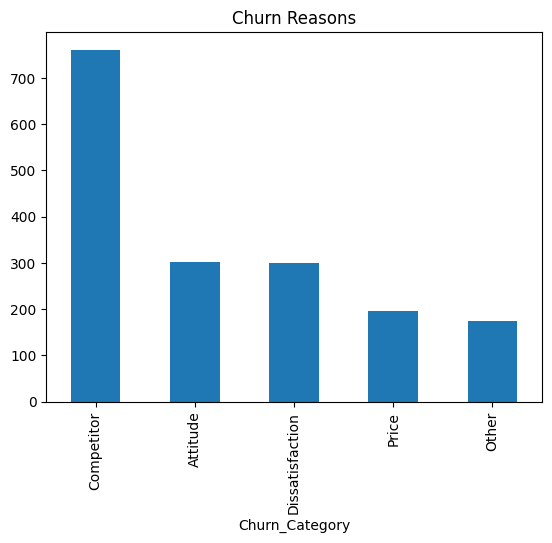

In [ ]:
df[df['Customer_Status'] == 'Churned']['Churn_Category'].value_counts().plot(kind='bar')
plt.title('Churn Reasons')
plt.show()